In this file I will load in cleaned data and epoch it based on events

In [71]:
#loading in req. packages
import mne
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import os.path as op
import warnings
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)
from mne.preprocessing import find_bad_channels_maxwell
import sys
import scipy

warnings.filterwarnings('ignore')

In [72]:
#load in cleaned data from derivatives / preprocessing
subject = '01'
session = '01'
task = 'face'
run = '01'
description = 'clean' 


bids_root = '/Users/rekaforgo/Documents/Bachelor2025'
deriv_root = op.join(bids_root, 'derivatives', 'preprocessing')

# Original raw file
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    run=run,
    description=description,
    suffix='meg',
    extension='.fif',
    root=deriv_root,
)

# --- LOAD RAW DATA ---
raw = read_raw_bids(bids_path=bids_path, verbose=True)
print(f"Loaded: {bids_path.fpath}")

Opening raw data file /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_desc-clean_meg.fif...
Isotrak not found
    Range : 0 ... 325339 =      0.000 ...   325.339 secs
Ready.
Loaded: /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/sub-01_ses-01_task-face_run-01_desc-clean_meg.fif


In [73]:
print(raw.info)


<Info | 13 non-empty values
 bads: 11 items (MEG05, MEG08, MEG16, MEG18, MEG29, MEG38, MEG40, ...)
 ch_names: MEG01, MEG02, MEG03, MEG04, MEG05, MEG06, MEG07, MEG08, MEG09, ...
 chs: 64 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 experimenter: PKU XU WEI
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | >
>


In [74]:
raw.load_data()
raw_filt = raw.copy().filter(l_freq=0.1, h_freq=40)

Reading 0 ... 325339  =      0.000 ...   325.339 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


In [75]:
tmin = -0.2
tmax = 0.8
epoch_proj_latency = 0.033 

In [76]:
events = mne.find_events(raw_filt, stim_channel='STIM', shortest_event=1, verbose=False)
events = mne.pick_events(events, include=1)

In [77]:
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    run=run,
    suffix='meg',
    extension='.fif',
    root=bids_root,
)

fname_behv = bids_path.copy().update(
    root=bids_root,
    datatype="beh",
    suffix="events",
    extension=".tsv",
    check=False,
).fpath

dat_behv = pd.read_csv(fname_behv, sep='\t')


In [78]:
stimlist = [int(r.split('.')[0][4:]) for r in dat_behv['stim_file']]
for i in range(len(stimlist)):
    if dat_behv['is_oneback'][i] == 0 and dat_behv['is_responsed'][i] == 1:
        stimlist[i] = 999  # exclude incorrect or unwanted trials
    if dat_behv['is_oneback'][i] == 1:
        stimlist[i] = 99   # mark one-back trials separately

In [79]:
stimlist = np.array(stimlist)
events[:, 2] = stimlist[stimlist != 99]  # assign event IDs
events = mne.pick_events(events, exclude=999)

In [80]:
# Apply projection latency correction (in samples)
events[:, 0] = events[:, 0] + int(epoch_proj_latency * raw.info['sfreq'])

In [81]:
epochs = mne.Epochs(
    raw_filt, events,
    tmin=tmin, tmax=tmax,
    baseline=(tmin, 0),
    detrend=1,
    picks='mag',
    preload=True,
    verbose=False
)

In [82]:
epoch_path = bids_path.copy().update(
    root=deriv_root,
    suffix='epo',
    extension='.fif',
    datatype='meg',
    check=False
)
epochs.save(epoch_path.fpath, overwrite=True)
print(f"Epochs saved to: {epoch_path.fpath}")

Overwriting existing file.
Overwriting existing file.
Epochs saved to: /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_epo.fif


Not setting metadata
256 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


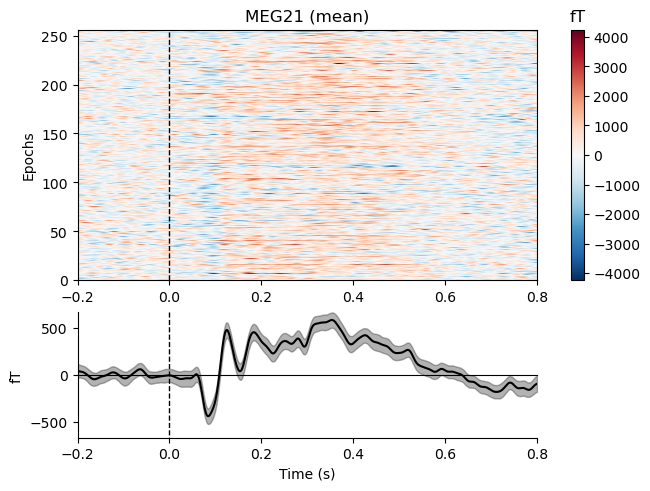

[<Figure size 640x480 with 3 Axes>]

In [83]:
epochs.plot_image(picks='MEG21', combine='mean')

Let's do simple TFR of Power based on it. 

Expectation: Expected response in the theta (0-250 / 150-250 ms, anterior regions) between neutral and joyful stimuli.

- need to find which event code corresponds to which event number


From experience we know that oscillations in slower frequency bands such as in the theta, alpha and beta range are fairly narrow-band (ΔF ~ 2 Hz) whereas neuronal activity in the gamma band (60 - 90 hz) is typically more broad-band (ΔF ~ 5-10 hz). For this reason we advise to use different settings for slower and faster frequencies.

We will be making use of the multi-taper technique. It is implemented as a sliding-time window approach where the Fourier transform is used to estimate the spectral power. In the MNE-Python implementation, the Fourier transform is based on a convolution-type approach. For the sliding window, data are 'tapered', i.e. one or more orthogonal tapers are multiplied to the data in the time-window prior to the Fourier-transform (Percival and Walden, 1993). These tapers are derived from discrete prolate spheroidal sequences (DPSS).

Prior to the analysis, there are 3 important parameters to set.

freqs: defines the frequency range over which to perform the analysis; in this case 2 to 30 Hz in 1 Hz steps.
n_cycles: defines the length of the sliding time-window in units of cycles. For instance, for f = 10 Hz a cycle is T = 1/10 Hz = 0.1 s long. We set n_cycles = freqs/2, i.e. for any frequency the time-window is ΔT = 500 ms (e.g. for f = 10 Hz, the variable n_cycles = 5 resulting in a ΔT = 500 ms time-window).
time_bandwidth: (2ΔTΔF) determines the number of DPSS tapers to be used. It is typically an even number and the number of tapers are then N = time_bandwidth - 1. The tapers relates to the temporal (ΔT) and spectral (ΔF) smoothing: N < 2 ΔT ΔF (Percival and Walden, 1993) . In this example we set time_bandwidth = 2.0, i.e. N = 1. This results in a spectral smoothing dF > 1 Hz. As we only use one taper for the slower frequencies the actual spectral smoothing is in fact 3/2 ΔT ~ 3 Hz
To calculate the TFR for all the planar gradiometers for attention left and right condition separately write:

In [84]:
freqs = np.arange(2, 31, 1)
n_cycles = freqs / 2 
time_bandwidth = 2.0

In [85]:
stim_ids = events[:, 2]
md = pd.DataFrame(dict(stim_id=stim_ids))
md['race']    = np.where(md.stim_id <= 32, 1, 2)
md['gender']  = np.where(((md.stim_id - 1) % 32) < 16, 1, 2)
md['age']     = np.where(((md.stim_id - 1) // 8) % 2 == 0, 1, 2)
md['emotion'] = np.where(((md.stim_id - 1) // 4) % 2 == 0, 1, 2)

epochs.metadata = md
print(epochs.metadata.head())

Adding metadata with 5 columns
   stim_id  race  gender  age  emotion
0       18     1       2    1        1
1       26     1       2    2        1
2        8     1       1    1        2
3       20     1       2    1        1
4       21     1       2    1        2


Now we can subset by using:

epochs_r1 = epochs['race == 1']

epochs_r2 = epochs['race == 2']

epochs_joy = epochs['emotion == 2']  

In [86]:



tfr_slow_neutral =  mne.time_frequency.tfr_multitaper(
    epochs['emotion == 1'], 
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'meg',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=2,
    n_jobs = -1,
    verbose=True)

tfr_slow_joy = mne.time_frequency.tfr_multitaper(
    epochs['emotion == 2'], 
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'meg',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=2,
    n_jobs= -1, 
    verbose=True)

NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done  53 out of  53 | elapsed:   28.1s finished


NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  53 out of  53 | elapsed:   14.3s finished
